## Imports

In [1]:
import sys
from pathlib import Path

project_base = Path.cwd().resolve().parents[1]
src_path = project_base / "src"
if src_path.exists():
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))
else:
    print(f"[ERROR] Engine not found: {src_path}")
    sys.exit(1)

import time, pickle, os
import multiprocessing as mp
from typing import Tuple, Any, List
import numpy as np
from memory_profiler import profile,LineProfiler, show_results
#from cryptography.x509 import name
from PolynomialMatrixBuilder import PolynomialMatrixBuilder
from matplotlib import pyplot as plt
import VeraGridEngine.api as vge
from VeraGridEngine.Templates.Rms.genqec_phasor_rms_template import get_genqec_phasor
from VeraGridEngine.Simulations.Rms.numerical.back_euler_fx import BackEulerImplicitIntegration
from phasor_diagnostics import (
    check_pf_line_equations,
    check_equation_consistency,
    debug_exciter_equations,
    check_generator_current_residuals as compare_generator_bus_currents,
    check_shunt_pf_currents,
    print_buses_with_many_injections,
    print_bus_current_balance,
)
from scipy.optimize import linear_sum_assignment
from VeraGridEngine.Utils.Symbolic.templates_common_functions import set_rms_model

from small_signal_tensygrid import op_extraction, solve_problem
import scienceplots
plt.style.use(['science', 'ieee', 'no-latex'])

C:\Users\Usuario\Desktop\git\VeraGrid\venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## Options

In [2]:
grid_folder = project_base / "Grids_and_profiles" / "grids"
GRID = "IEEE 9 Bus.gridcal"
#GRID = "IEEE39.gridcal"
USE_CACHED_BUILDER = False
BUILDER_CACHE_FILE = f'trunk/tensygrid/precomputed_builds/{GRID}.pkl'

In [3]:
REPORT_TIME = False

FAST_MODE = False
LOGS = False
FULL_GRID_PATH = str(grid_folder / GRID)
FAST_GRID_PATH = FULL_GRID_PATH
PRINT_ALL_BUSES = LOGS
ENABLE_POST_COMPARE_PLOT = LOGS
RUN_DYNAMIC_STEP = False
RUN_CONSISTENCY_CHECK = False
RUN_PF_LINE_EQ_CHECK = False
RUN_EXCITER_DIAGNOSTICS = False
PF_LINE_FOCUS_INDEX = 0
DYNAMIC_SIM_TIME_FAST = 0.05
DYNAMIC_SIM_TIME_FULL = 0.20

EXEC_METRICS = {
    "n_vars": 0,
    "t_builder": 0.0,
    "t_solve": 0.0,
    "is_sparse": False,
    "stops":0
}

## Code

In [4]:
def define_problem_with_path(grid_path):
    """Creates the grid, runs the power flow, and returns the phasor problem."""
    print("\n[1] Creating phasor grid_path...")
    grid = vge.open_file(grid_path)

    # Build RMS models
    # Things we need to add: buses, branches, generators, transformers, loads, shunts

    ## BUSES:
    for bus in grid.buses:
        busec = vge.initialize_bus_phasor_rms(bus, vf=grid.var_factory)

    ## -GENERATORS
    for igen, gen in enumerate(grid.generators):
        genqec = vge.get_complete_generator_template_phasor(grid.var_factory, name=f"Gen{igen}").block


        grid.var_factory.add_connections([genqec.in_vars[0]], [gen.bus.rms_model.out_vars[0]])

        grid.var_factory.add_connections([genqec.in_vars[1]], [gen.bus.rms_model.out_vars[1]])
        set_rms_model(device=gen, model=genqec, var_factory=grid.var_factory)

    ## -LINES:
    for line in grid.lines:
        lineec = vge.get_line_phasor_rms_template(grid.var_factory, name=line.name).block
        grid.var_factory.add_connections([lineec.in_vars[0]], [line.bus_from.rms_model.out_vars[0]])
        grid.var_factory.add_connections([lineec.in_vars[1]], [line.bus_from.rms_model.out_vars[1]])
        grid.var_factory.add_connections([lineec.in_vars[2]], [line.bus_to.rms_model.out_vars[0]])
        grid.var_factory.add_connections([lineec.in_vars[3]], [line.bus_to.rms_model.out_vars[1]])
        lineec = vge.to_implicit(lineec, grid.var_factory)
        set_rms_model(device=line, model=lineec, var_factory=grid.var_factory)
    ## -LOADS:
    for load in grid.loads:
        loadec = vge.get_load_phasor_current_rms_template(grid.var_factory, name=load.name).block
        grid.var_factory.add_connections([loadec.in_vars[0]], [load.bus.rms_model.out_vars[0]])
        grid.var_factory.add_connections([loadec.in_vars[1]], [load.bus.rms_model.out_vars[1]])
        #loadec = vge.to_implicit(loadec, grid.var_factory)
        set_rms_model(device=load, model=loadec, var_factory=grid.var_factory)
    ## -TRANSFORMERS 2w:
    for trafo in grid.transformers2w:
        trafoec = vge.initialize_trafo_rms(trafo, grid.var_factory, use_phasor_template=True).block
        grid.var_factory.add_connections([trafoec.in_vars[0]], [trafo.bus_from.rms_model.out_vars[0]])
        grid.var_factory.add_connections([trafoec.in_vars[1]], [trafo.bus_from.rms_model.out_vars[1]])
        grid.var_factory.add_connections([trafoec.in_vars[2]], [trafo.bus_to.rms_model.out_vars[0]])
        grid.var_factory.add_connections([trafoec.in_vars[3]], [trafo.bus_to.rms_model.out_vars[1]])
        trafoec = vge.to_implicit(trafoec, grid.var_factory)
        vge.set_rms_model(device=trafo, model=trafoec, var_factory=grid.var_factory)
    ## -SHUNTS (load like):
    for shunt in grid.shunts:
        shuntec = vge.get_shunt_template(grid.var_factory, name=shunt.name, phasor=True).block
        grid.var_factory.add_connections([shuntec.in_vars[0]], [shunt.bus.rms_model.out_vars[0]])
        grid.var_factory.add_connections([shuntec.in_vars[1]], [shunt.bus.rms_model.out_vars[1]])
        shuntec = vge.to_implicit(shuntec, grid.var_factory)
        set_rms_model(device=shunt, model=shuntec, var_factory=grid.var_factory)

    # TRANSFORMERS 3W: Not present in existing grids and not supported
    print("  ✓ Grid with path loaded")

    # ===================================================================
    # POWER FLOW
    # ===================================================================

    print("\n[2] Running power flow...")
    #pf_options = vge.PowerFlowOptions(tolerance=1e-13)
    pf_options = vge.PowerFlowOptions(tolerance=1e-5)
    pf_results = vge.power_flow(grid, pf_options)

    if pf_results.converged:
        print(f"  ✓ Power flow converged")
        if PRINT_ALL_BUSES:
            for i, bus in enumerate(grid.buses):
                v = pf_results.voltage[i]
                print(f"    {bus.name}: Vm={abs(v):.4f} pu")
        else:
            vm = np.abs(pf_results.voltage)
            print(f"    Buses: {len(grid.buses)}, Vm[min/avg/max]=({vm.min():.4f}/{vm.mean():.4f}/{vm.max():.4f}) pu")
    else:
        print("  ✗ Power flow failed")
        return False

    if RUN_PF_LINE_EQ_CHECK:
        check_pf_line_equations(grid=grid, pf_results=pf_results)

    check_shunt_pf_currents(grid=grid, pf_results=pf_results)
    print("\n[2.7] Buses with multiple injection devices...")
    print_buses_with_many_injections(grid=grid)
    print_bus_current_balance(grid=grid, pf_results=pf_results)
    # ===================================================================
    # CREATE PHASOR PROBLEM
    # ===================================================================
    print("\n[3] Creating phasor problem...")

    rms_options = vge.RmsOptions(
        time_step=0.01,
        simulation_time=1.0,
        tolerance=1e-6,
        max_iter=20,
        verbose=True,
    )

    start_time= time.perf_counter()
    phasor_problem = vge.RmsProblemPhasor(grid=grid, options=rms_options, pf_results=pf_results)
    EXEC_METRICS["n_vars"] = phasor_problem.get_all_vars_number()
    end_time= time.perf_counter()
    print(f"\n[3.1.0] ⏰ Func phasor_problem took {end_time - start_time:.2f} seconds")
    print(f"  ✓ Phasor problem created with {phasor_problem.get_states_number()} states")
    if RUN_CONSISTENCY_CHECK:
        check_equation_consistency(phasor_problem)
    if RUN_EXCITER_DIAGNOSTICS:
        debug_exciter_equations(phasor_problem)
        compare_generator_bus_currents(problem=phasor_problem, pf_results=pf_results)
    print("\n[3.0] Exciter diagnostics...")
    #debug_exciter_equations(problem=phasor_problem)
    # ===================================================================
    # DYNAMIC VALIDATION
    # ===================================================================
    if RUN_DYNAMIC_STEP:
        print("\n[3.1.1] Running dynamic simulation...")
        dyn_t_end = DYNAMIC_SIM_TIME_FAST if FAST_MODE else DYNAMIC_SIM_TIME_FULL
        solver = BackEulerImplicitIntegration(
            problem=phasor_problem,
            t0=0,
            t_end=dyn_t_end,
            h=rms_options.time_step,
            max_iter=rms_options.max_iter,
            tolerance=rms_options.tolerance,
        )
        t_dyn, y_dyn, well_initialized, converged = solver.simulate()
        print(
            f"  ✓ Dynamic simulation finished: steps={len(t_dyn)}, "
            f"well_initialized={well_initialized}, converged={converged}, "
            f"final|x|={np.linalg.norm(y_dyn[-1, :]):.4e}"
        )
    return phasor_problem

def solve_problem(problem: Any = None) -> Any:

    builder = None

    if USE_CACHED_BUILDER and os.path.exists(BUILDER_CACHE_FILE):
        print(f"\n[📦] Loading builder object from '{BUILDER_CACHE_FILE}'...")
        with open(BUILDER_CACHE_FILE, 'rb') as f:
            builder = pickle.load(f)

        # Reassign the problem we just created/loaded in the main script
        print("  ✓ Builder restored successfully (skipping linearization)")

    else:

        print("\n[4] Rebuilding equations and extracting exact physics...")
        builder = PolynomialMatrixBuilder(problem=problem, verbose=True)
        v_dict: dict = op_extraction(problem=problem)

        print("\n[*] Linearizing model with real parameters...")
        builder.linearize(v_dict=v_dict)
            # 2. If it does not exist, build it from scratch and save it

        if USE_CACHED_BUILDER:
            print(f"\n[📦] Saving full builder object to '{BUILDER_CACHE_FILE}'...")
            with open(BUILDER_CACHE_FILE, 'wb') as f:
                pickle.dump(builder, f)
            print("  ✓ Builder saved successfully")

    # Continue with the normal stability analysis
    # Use automatic routing: sparse for large systems, dense fallback otherwise.
    res = builder.compute_stability()

    eigenvalues = res[0]
    #print(eigenvalues)
    stable = res[4]
    margin = res[5] if res[5] is not None else 0.0
    participation_matrix = res[3] if res[3] is not None else None

    print("\n" + "=" * 80)
    print("SMALL SIGNAL ANALYSIS COMPLETE - POLYNOMIAL BUILDER")
    print("=" * 80)
    print(f"  Found {len(eigenvalues)} finite eigenvalues")
    print(f"  System is stable: {stable}")
    print(f"  Stability margin: {margin:.4f}")
    print("=" * 80)

    # Extract the mapping using the class's corrected function
    pf_map: dict = builder.get_participation_mapping(eigenvalues, participation_matrix)

    print("\n" + "!" * 80)
    print("!!! UNSTABLE MODE ANALYSIS (Re > 0)")
    print("!" * 80)

    unstable_found = False
    for ev, participations in pf_map.items():
        # Strictly filter poles in the right half-plane
        if ev.real > 1e-6:
            unstable_found = True
            print(f"\n🚨 Critical mode: {ev.real:.4f} + {ev.imag:.4f}j")
            if not participations:
                print("  -> [!] No dominant physical variables (check structural patch)")
            for var_name, pf in participations:
                print(f"  -> {var_name}: {pf * 100:.1f}%")

    if not unstable_found:
        print("\n✅ The system is stable! There is no real part greater than 0.")
    return res, pf_map, builder

def op_extraction(problem: vge.RmsProblemPhasor) -> dict:
    """
    Returns the operating point dictionary from a defined VeraGrid problem.
    """
    v_dict: dict = dict()
    def safe_get_value(val):
        try:
            return float(val)
        except:
            if hasattr(val, 'value'):
                try:
                    return float(val.value)
                except:
                    pass
        return None

    # 3. EXTRACT x0 (Equilibrium point)
    try:
        x0 = problem.get_x0()
        for i, sym in enumerate(problem.state_and_algebraic_vars):
            v_dict[str(sym.name)] = float(x0[i])
    except Exception:
        pass

    # 4. EXTRACTION FROM THE PHOTO PATHS
    if hasattr(problem, '_variable_parameters') and hasattr(problem, '_variable_parameters_values'):
        names = problem._variable_parameters
        values = problem._variable_parameters_values
        if names is not None and values is not None:
            # If values is a list/array and names contains the symbols
            for name_obj, val_obj in zip(names, values):
                s_name = str(name_obj.name) if hasattr(name_obj, 'name') else str(name_obj)
                val = safe_get_value(val_obj)
                if val is not None:
                    v_dict[s_name] = val

    # Backup just in case there are also fixed constants
    if hasattr(problem, '_constant_parameters') and hasattr(problem, '_constant_params'):
        for n, v in zip(problem._constant_parameters, problem._constant_params):
            s_name = str(n.name) if hasattr(n, 'name') else str(n)
            val = safe_get_value(v)
            if val is not None:
                v_dict[s_name] = val

    return v_dict


In [5]:
# --- START CHRONO ---
start_time = time.perf_counter()

grid_path = FAST_GRID_PATH if FAST_MODE else FULL_GRID_PATH
print(f"[FAST_MODE={FAST_MODE}] Using grid: {grid_path}")

problem = None
calculated_evs = []

# 1. Check whether the builder cache exists BEFORE creating the problem
if USE_CACHED_BUILDER and os.path.exists(BUILDER_CACHE_FILE):
    print(f"\n[⏩] File '{BUILDER_CACHE_FILE}' found.")
    print("[⏩] Skipping Phasor Problem creation...")
    print(f"\n[📦] Loading builder object from '{BUILDER_CACHE_FILE}'...")
    with open(BUILDER_CACHE_FILE, 'rb') as f:
        builder = pickle.load(f)
    # Keep problem as None. solve_problem will load the .pkl internally.
    res, pf_map, builder = solve_problem(problem=problem)
    calculated_evs = res[0]
else:
    # 2. If there is no cache, run the normal heavy simulation
    problem = define_problem_with_path(grid_path)
    if problem:
        # Pass the newly created problem so it can be linearized and cached
        res, pf_map, builder = solve_problem(problem=problem)
        calculated_evs = res[0]

# --- END CHRONO ---
end_time = time.perf_counter()
total_duration = end_time - start_time

print(f"\n========================================")
print(f"EXECUTION TIME: {total_duration:.4f} seconds")
print(f"========================================")

[FAST_MODE=False] Using grid: C:\Users\Usuario\Desktop\git\VeraGrid\Grids_and_profiles\grids\IEEE 9 Bus.gridcal

[1] Creating phasor grid_path...
  ✓ Grid with path loaded

[2] Running power flow...
  ✓ Power flow converged
    Buses: 9, Vm[min/avg/max]=(0.9956/1.0220/1.0400) pu

[2.7] Buses with multiple injection devices...
  No buses with >= 3 injection devices found.

[2.8] Bus current balance report...
  buses over tol=1.0e-08: 8
  bus 7        |err|=4.619940e-07 Br=(3.536e-07,-2.974e-07) G=(0.000e+00,0.000e+00) Bt=(0.000e+00,0.000e+00) L=(0.000e+00,0.000e+00) Sh=(0.000e+00,0.000e+00) Sl=(0.000e+00,0.000e+00) R=(3.536e-07,-2.974e-07)
  bus 8        |err|=2.927901e-07 Br=(-1.218e+00,5.883e-01) G=(0.000e+00,0.000e+00) Bt=(0.000e+00,0.000e+00) L=(-1.218e+00,5.883e-01) Sh=(0.000e+00,0.000e+00) Sl=(0.000e+00,0.000e+00) R=(-1.091e-07,-2.717e-07)
  bus 6        |err|=1.981409e-07 Br=(-9.887e-01,3.320e-01) G=(0.000e+00,0.000e+00) Bt=(0.000e+00,0.000e+00) L=(-9.887e-01,3.320e-01) Sh=(0.000

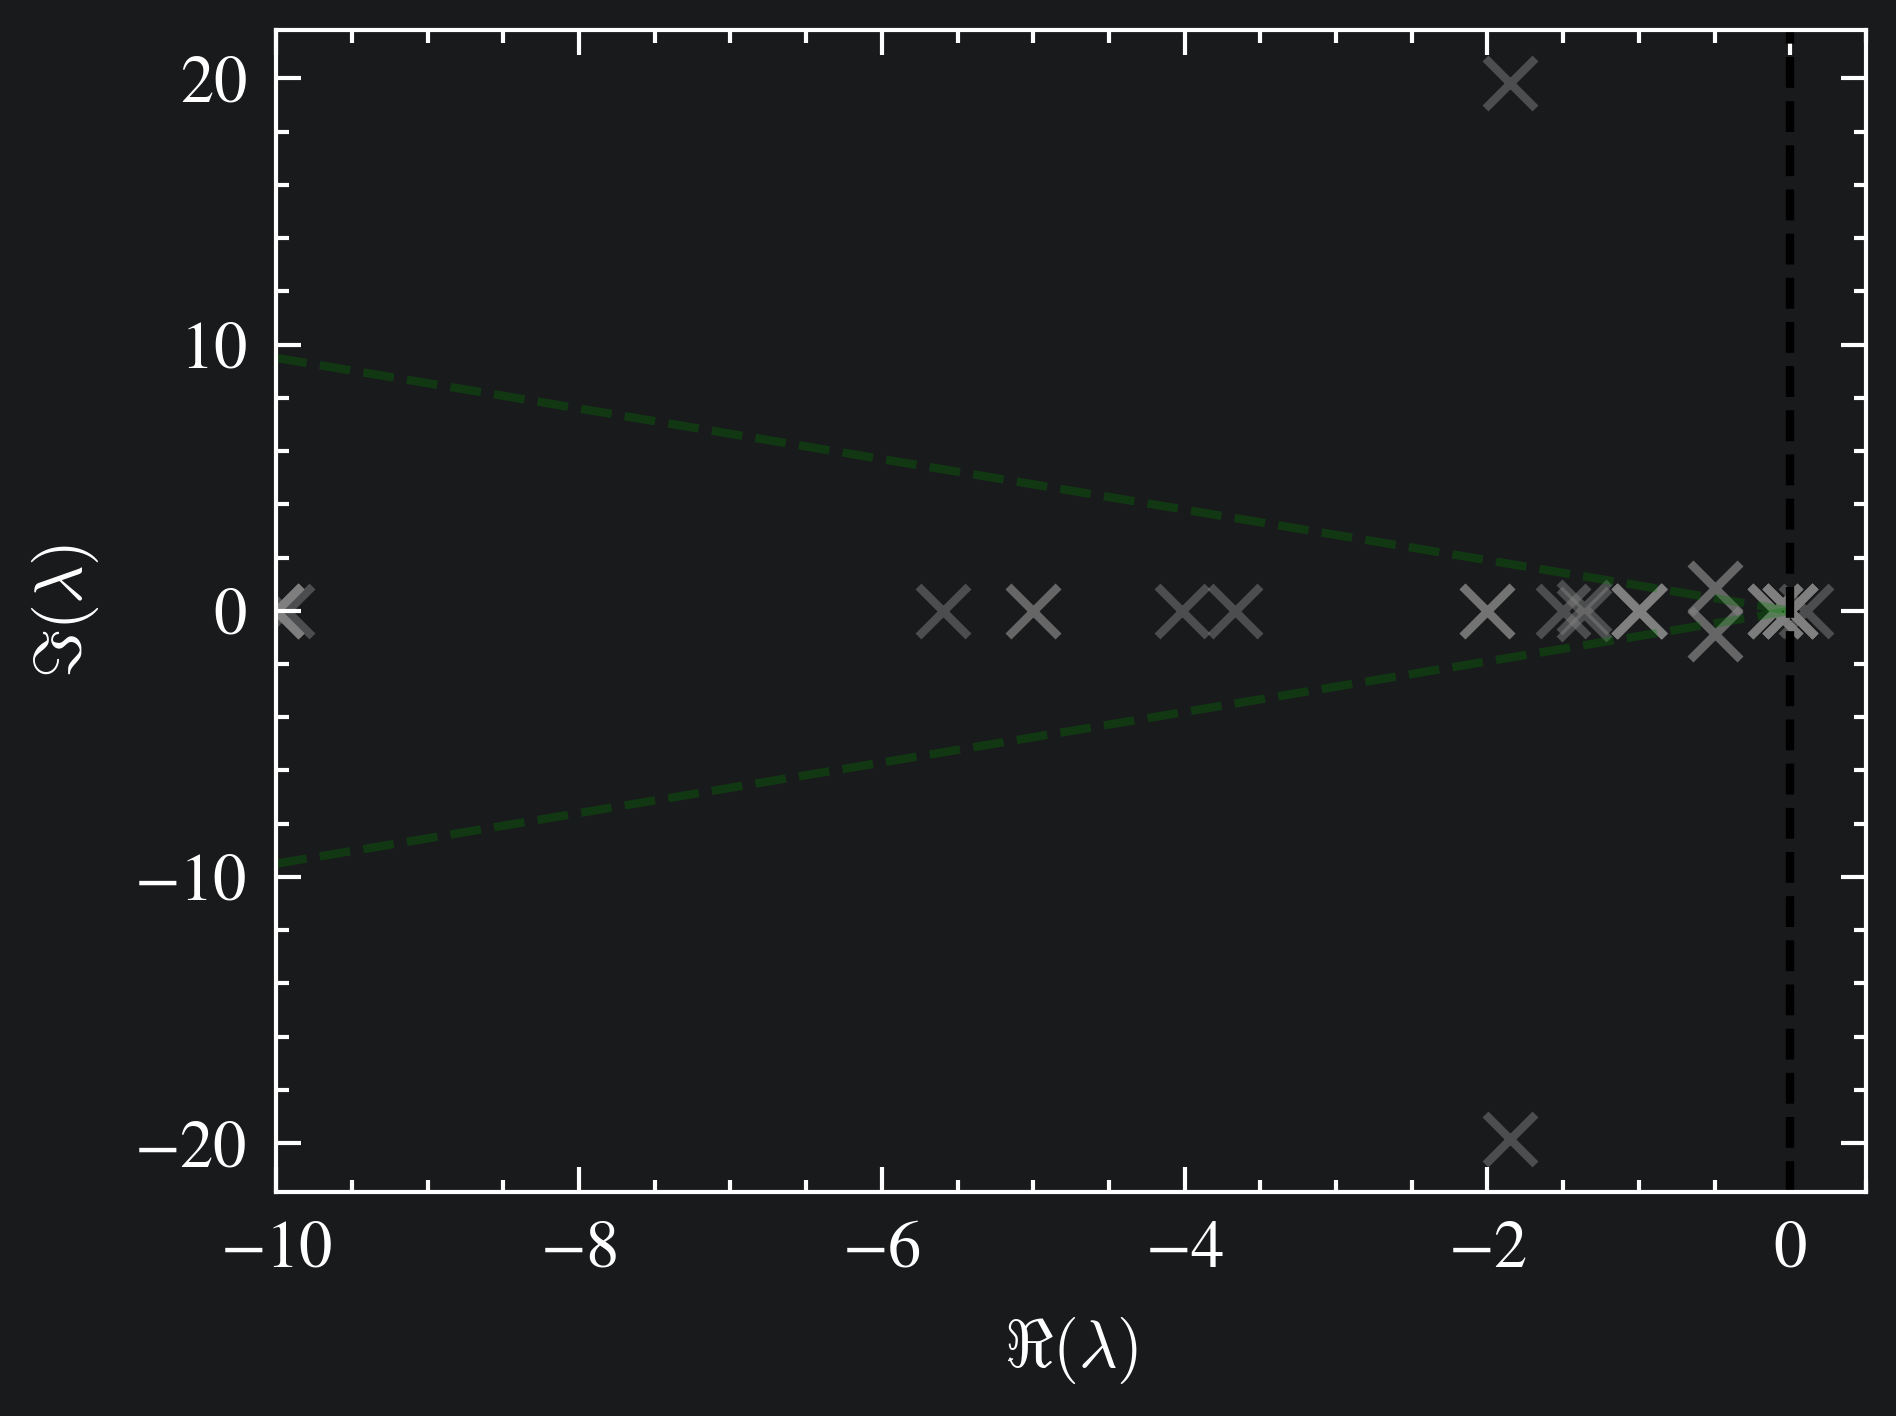

In [6]:
plt.scatter(np.real(calculated_evs), np.imag(calculated_evs),
                color='gray', marker='x', alpha=0.5)
xs = np.arange(-10, 1, 1)
ys = 0.95*xs
plt.plot(xs, ys, color='green', alpha=0.3, linestyle='dashed')
plt.plot(xs, -ys, color='green', alpha=0.3, linestyle='dashed')

plt.xlabel("$\\Re({\\lambda})$")
plt.ylabel("$\\Im({\\lambda})$")
plt.xlim(-10,0.5)
plt.axvline(0, linestyle='--', color='k')
plt.tight_layout()
plt.show()

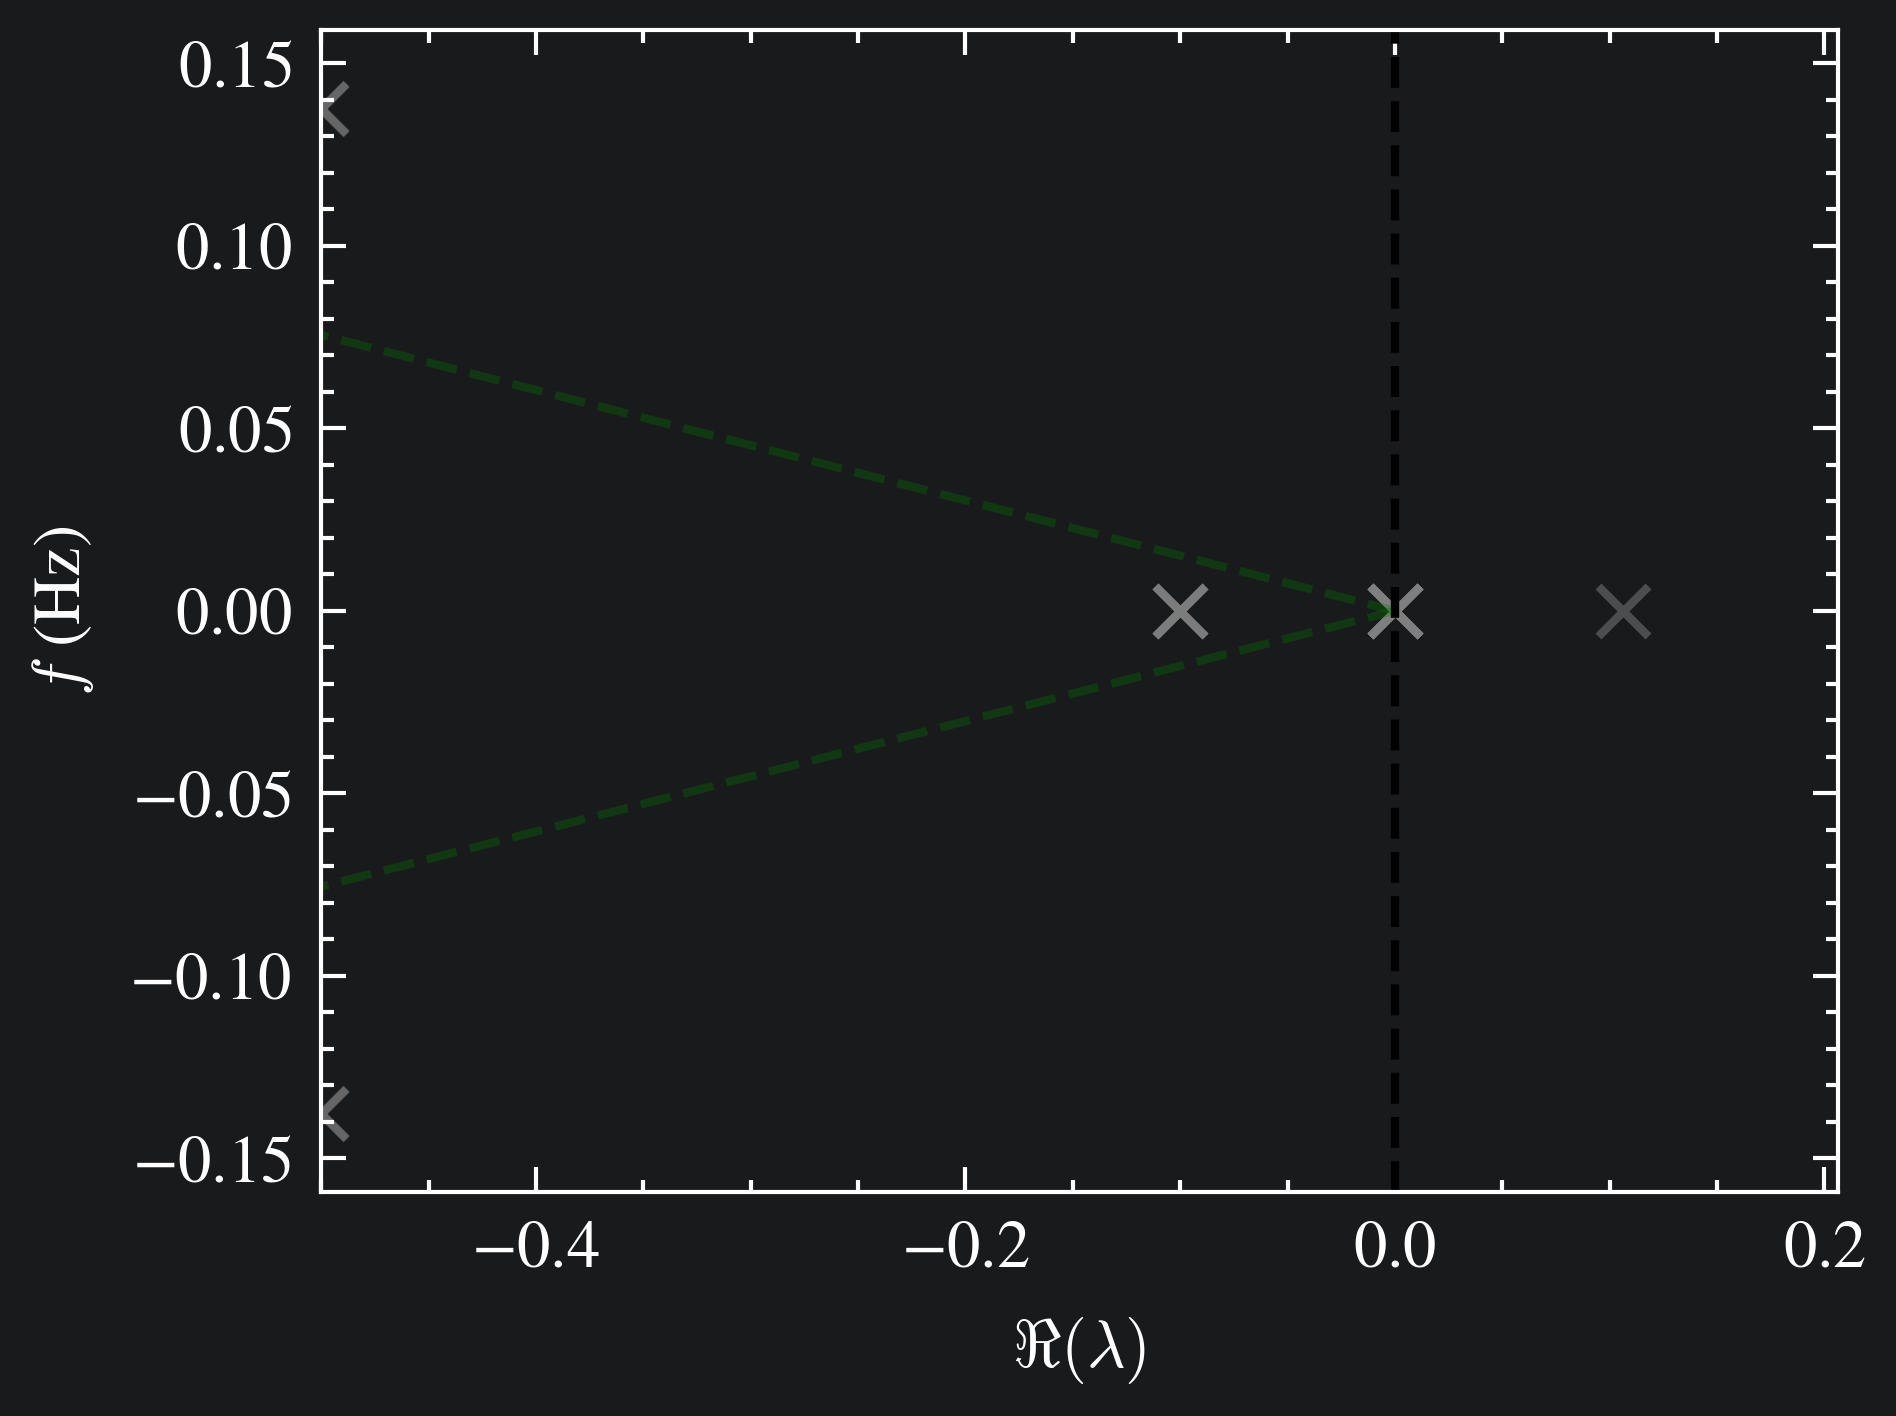

In [7]:
plt.scatter(np.real(calculated_evs), np.imag(calculated_evs)/(2*np.pi),
                color='gray', marker='x', alpha=0.5, label="Pablo's computation")
xs = np.arange(-10, 1, 1)
ys = 0.95*xs/(2*np.pi)
plt.plot(xs, ys, color='green', alpha=0.3, linestyle='dashed')
plt.plot(xs, -ys, color='green', alpha=0.3, linestyle='dashed')

plt.xlabel("$\\Re({\\lambda})$")
plt.ylabel("$f$ (Hz)")
plt.xlim(-0.5, max(np.real(calculated_evs))+0.1)
plt.ylim(-1/(2*np.pi),1/(2*np.pi))
plt.axvline(0, linestyle='--', color='k')
plt.tight_layout()
plt.show()

In [8]:
for ev, participations in pf_map.items():
    if -0.01 < np.real(ev) <= 0.1:
        print(f"\n--- Autovalor: {ev:.2f} ---")
        for var_name, pf in participations:
            #if not str(var_name).startswith("u_"):
                print(f"  -> Variable {var_name}: {pf * 100:.2f}%")


--- Autovalor: 0.00+0.00j ---


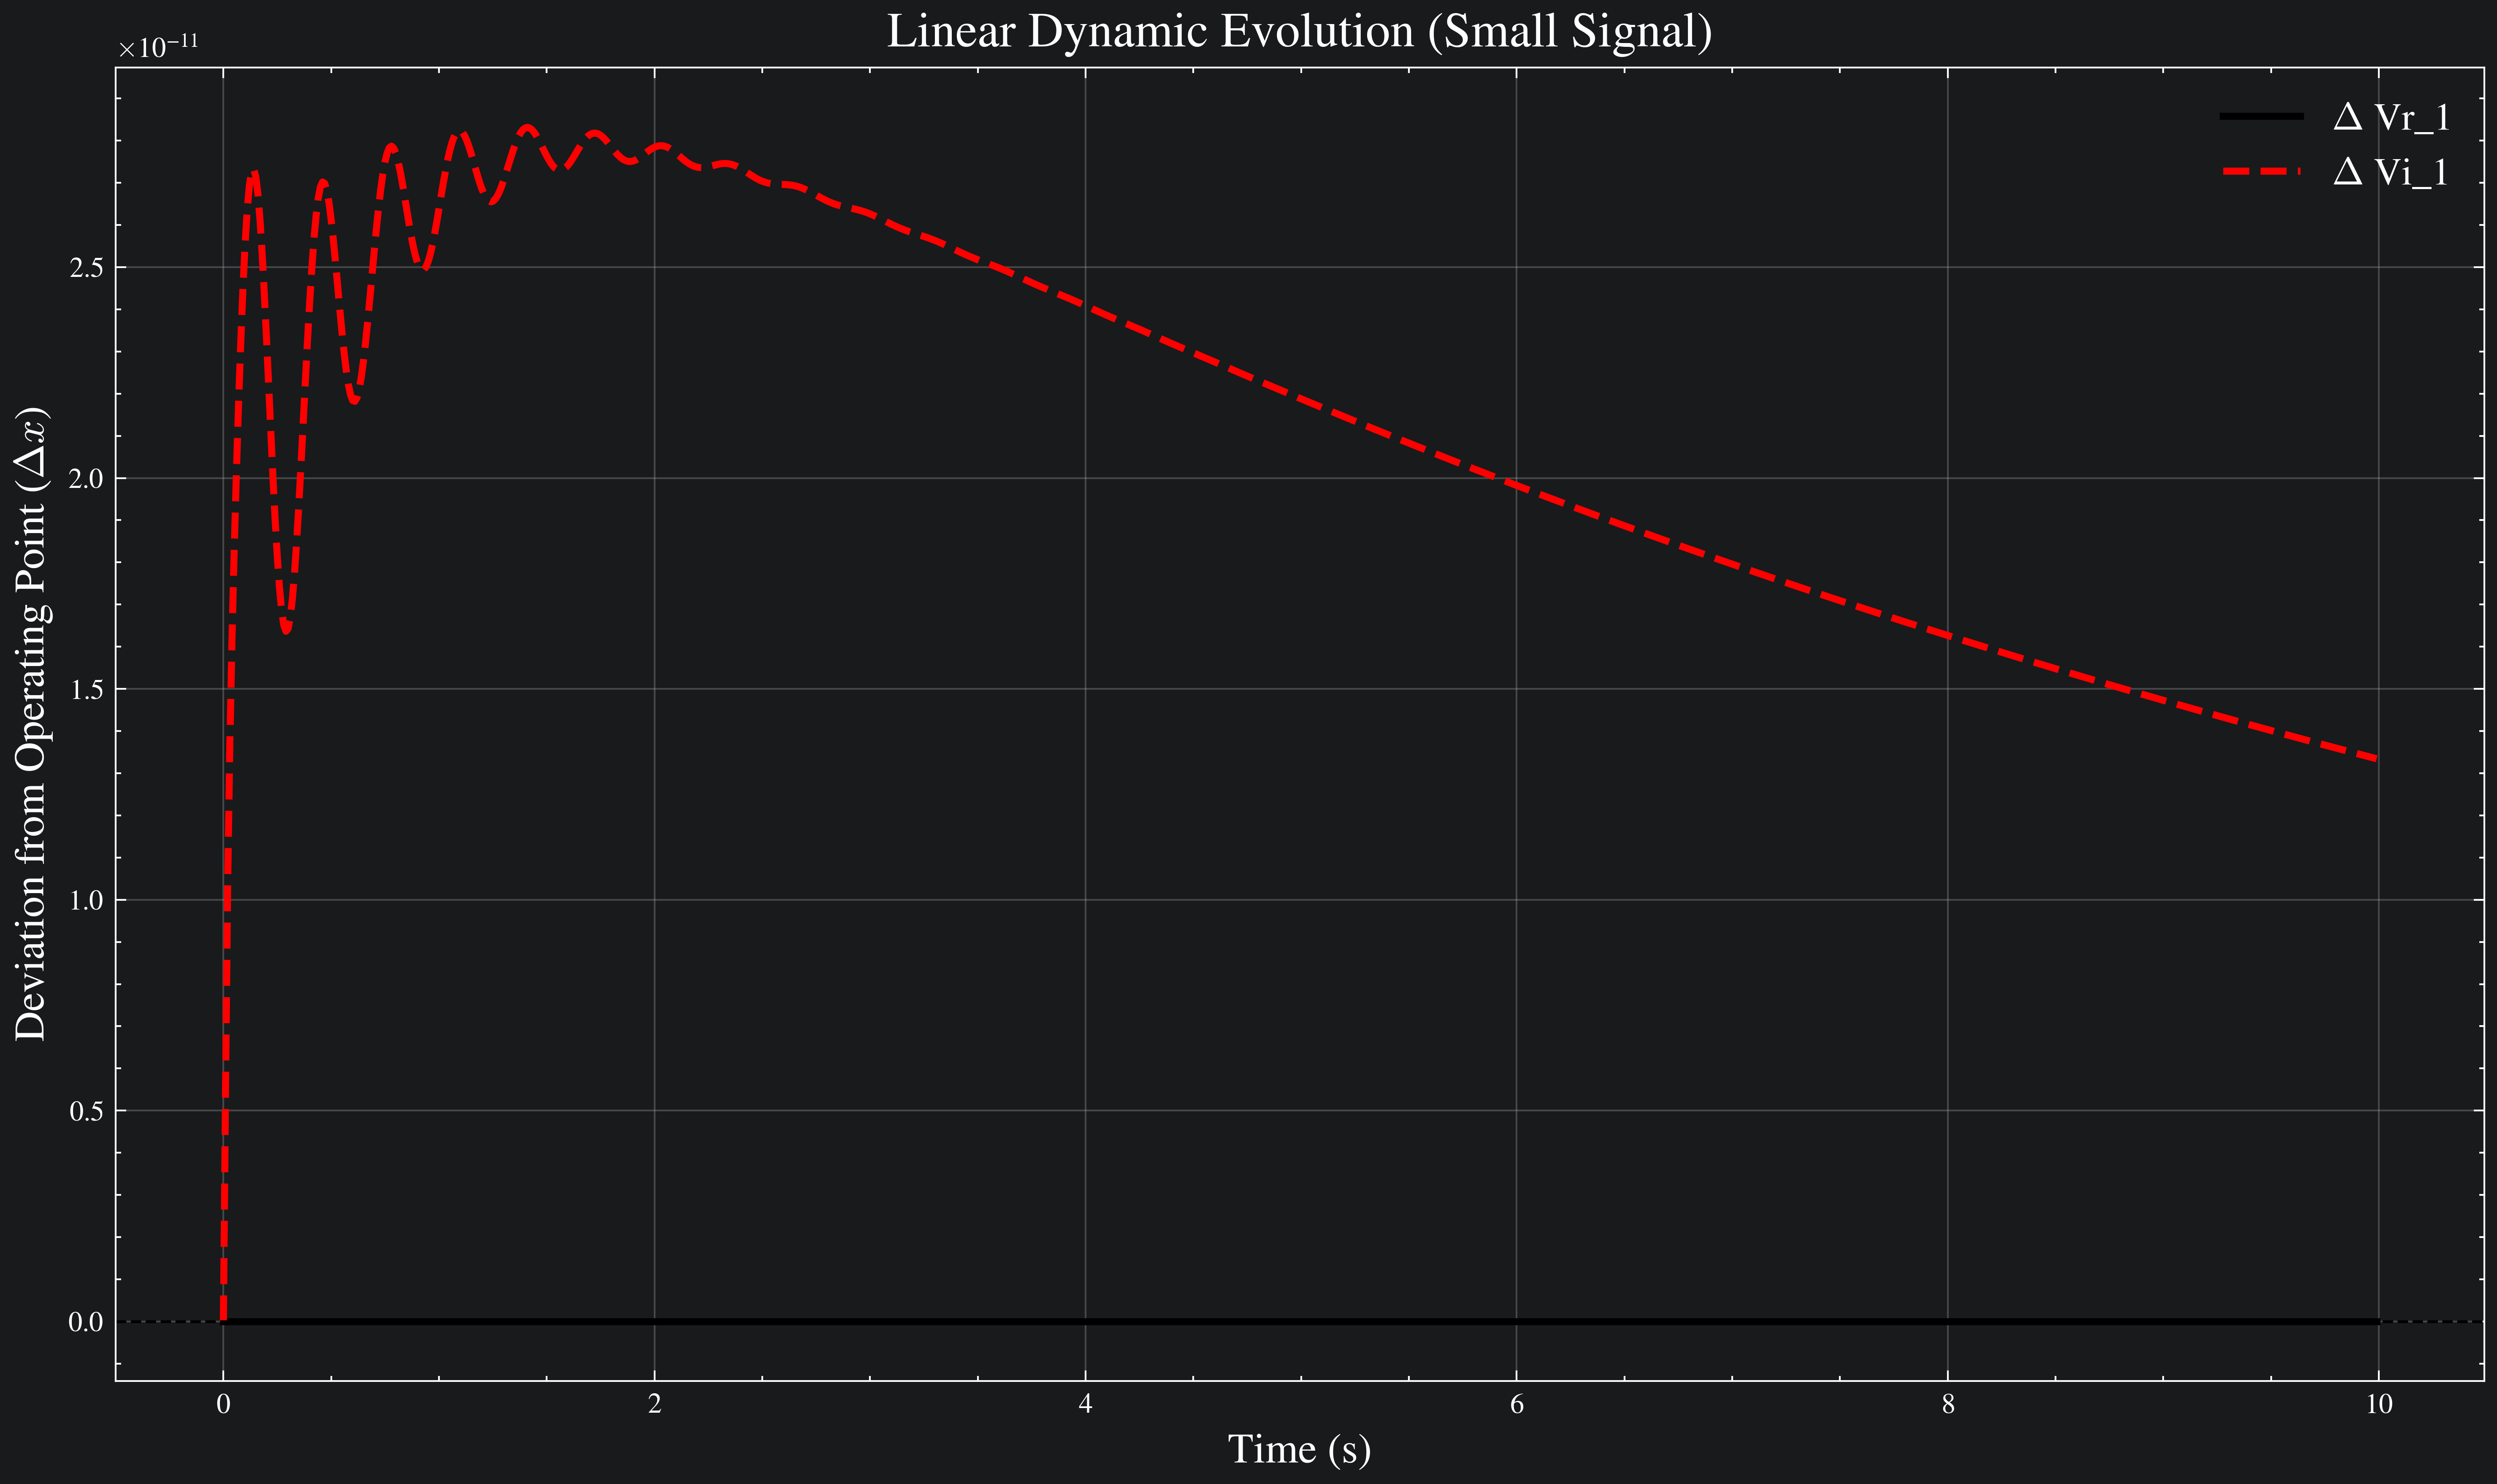

In [9]:
op_dict = op_extraction(problem=problem)

perturbation_dict = {k: 0.0 for k in op_dict.keys()}
perturbation_dict["Vr_1"] = -0.5

builder.plot_evolution(
    t_f=10.0,
    timestep=0.01,
    v_dict=perturbation_dict,
    evals=res[0],
    evecs=res[2],
    variables=["Vr_1", "Vi_1"]
)

In [10]:
bifurcation_report = builder.compute_bifurcation_stability(
    pf_map=pf_map,
    evals=res[0],
    evecs=res[2],
    margin=0.05,
    tolerance=1e-2)


[ Bifurcation & Stability Analysis | Margin: +/-0.05 | Time: 5.0s ]

--- Critical Eigenvalue Detected: 0.0000+0.0000j ---
    (Frequency: 0.00 Hz, Damping: 0.00%)


In [11]:
for mode, vars_eval in bifurcation_report.items():
    for result in vars_eval:
        if not result["passed"]:
            print(f"Programmatic alert: The system will lose stability due to bifurcation at {result['variable']}")